In [27]:
import os
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Crack_IVF_hybrid_search_version import CrackIVFHybridSearch

DATASETS = {
    "SIFT1M": {
        "dimension": 128,
        "docs": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/sift/sift_docs.csv",
        "queries": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/sift/sift_queries.csv",
        "output": "/home/salemmohammed/Projects/research-projects/HyVec/results/raw/GTTest/sift_ground_truth_k1000.npz",
        "attribute": "rand_int",
        "K": 1000,
    },
    "PAPER": {
        "dimension": 200,
        "docs": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/paper/paper_docs.csv",
        "queries": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/paper/paper_queries.csv",
        "output": "/home/salemmohammed/Projects/research-projects/HyVec/results/raw/GTTest/paper_ground_truth_k1000.npz",
        "attribute": "rand_int",
        "K": 1000,
    },
    "BIER": {
        "dimension": 1024,
        "docs": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/beir/beir_docs.csv",
        "queries": "/home/salemmohammed/Projects/research-projects/HyVec/data/hnsw/beir/beir_queries.csv",
        "output": "/home/salemmohammed/Projects/research-projects/HyVec/results/raw/GTTest/bier_ground_truth_k1000.npz",
        "attribute": "source",
        "K": 1000,
    },
}

In [28]:
def parse_vector(vector_string):
    return np.fromstring(str(vector_string),sep=",",dtype=np.float32)

In [29]:
def load_dataset(dataset_name,config):

    print("\n" + "=" * 70)
    print(f"Loading {dataset_name}")
    print("=" * 70)

    docs_df = pd.read_csv(config["docs"], sep=";")

    queries_df = pd.read_csv(config["queries"],sep=";")

    print(f"Documents : {len(docs_df):,}")
    print(f"Queries   : {len(queries_df):,}")

    return docs_df, queries_df

In [30]:
def prepare_dataset_arrays(
    dataset_name,
    docs_df,
    queries_df,
    expected_dimension,
    attribute_column,
    verbose=False,
    verbose_n=5,
):
    """
    Parse embeddings and extract metadata arrays.
    """

    print(f"Parsing {dataset_name} document vectors...")

    document_vector_list = [parse_vector(value) for value in docs_df["embedding"]]

    # Validate every document vector.
    for row_number, vector in enumerate( document_vector_list):
        if vector.size != expected_dimension:
            raise ValueError(
                f"{dataset_name} document row "
                f"{row_number} has dimension "
                f"{vector.size}; expected "
                f"{expected_dimension}."
            )

    database_vectors = np.vstack(document_vector_list).astype(np.float32,copy=False)

    del document_vector_list

    print(f"Parsing {dataset_name} query vectors...")

    query_vector_list = [parse_vector(value) for value in queries_df["embedding"]]
    
    if verbose:
        print(f"\n--- Sample of {verbose_n} query rows (before/after parsing) ---")
        for i in range(min(verbose_n, len(query_vector_list))):
            raw = queries_df["embedding"].iloc[i]
            parsed = query_vector_list[i]
            print(f"[query {i}] raw (first 60 chars): {str(raw)[:60]}...")
            print(f"[query {i}] parsed shape: {parsed.shape}, first 5 values: {parsed[:5]}")

    # Validate every query vector.
    for row_number, vector in enumerate(query_vector_list):
        if vector.size != expected_dimension:
            raise ValueError(
                f"{dataset_name} query row "
                f"{row_number} has dimension "
                f"{vector.size}; expected "
                f"{expected_dimension}."
            )

    query_vectors = np.vstack(query_vector_list).astype(np.float32,copy=False)

    del query_vector_list

    # Extract metadata.
    database_attributes = docs_df[ attribute_column].to_numpy()

    query_attributes = queries_df[attribute_column].to_numpy()

    # Create numeric IDs.
    database_ids = np.arange(database_vectors.shape[0],dtype=np.int64)

    query_ids = np.arange(query_vectors.shape[0], dtype=np.int64)
    
    if verbose:
        print(f"\n--- Sample of {verbose_n} attributes ---")
        print(f"Database attributes[:{verbose_n}]: {database_attributes[:verbose_n]}")
        print(f"Query    attributes[:{verbose_n}]: {query_attributes[:verbose_n]}")
        print(f"Database attribute dtype: {database_attributes.dtype}")
        print(f"Query    attribute dtype: {query_attributes.dtype}")

    print("Database shape:", database_vectors.shape)
    print("Query shape:", query_vectors.shape)

    return (
        database_vectors,
        query_vectors,
        database_ids,
        query_ids,
        database_attributes,
        query_attributes,
    )

In [31]:
index = CrackIVFHybridSearch(
    nlist=100,           # paper's minimal starting partitions, not 1000
    default_nprobe=10,
    niter=10,
    max_pts=100000,
    metric="euclidean",
    dbname="SIFT1M",
    nthreads=16          # matches paper + removes the CostEstimator warning
)

CrackIVF initialized: self.nlist=100, self.niter=10, self.max_pts=100000, self.seed=42, self.metric_str='euclidean', self.MIN_PTS_AFTER_CRACK=2, self.THRESHOLD_PTS_PER_CENT=64, self.alpha=0.5, self.cv_max=2, self.size_prcnt_low=10, self.size_prcnt_high=90 | dbname=SIFT1M | nthreads=16


In [32]:
xb = np.random.rand(100, 8).astype(np.float32)
index.add(xb)

Init Index... self.nlist=100 self.niter=10 self.max_pts=100000 self.seed=42 self.D=8
Adding 100000 distance computations for index.train
Adding 0 distance computations for index.add_and_search
	---> Index Train Time = 0.06718398071825504 ms | Add Time = 1.628455938771367 ms<---


WARNING clustering 100 points to 100 centroids: please provide at least 3900 training points


(6.718398071825504e-05, 0.001628455938771367)

In [33]:
attributes_dataset = np.random.randint(0, 3, size=len(xb)).tolist()
index.populate_attribute_list(attributes_dataset)

In [34]:
def replicate_queries(xq, xq_attrs, target_queries):
    n_unique = xq.shape[0]
    n_repeats = -(-target_queries // n_unique)  # ceiling division
    
    print(f"Original number of queries: {n_unique}")
    print(f"Target number of queries: {target_queries}")
    print(f"Number of repetitions: {n_repeats}")
    
    xq_trace = np.tile(xq, (n_repeats, 1))[:target_queries]
    xq_attrs_trace = np.tile(xq_attrs, n_repeats)[:target_queries]
    
    n_replicated = xq_trace.shape[0]
    print(f"Actual number of queries after replication: {n_replicated}")
    
    augmented_values = np.column_stack((xq_trace, xq_attrs_trace))
    print("Augmented values:")
    print(augmented_values)
    
    return xq_trace, xq_attrs_trace, n_replicated

In [35]:
def load_ground_truth(output_path, k=1000):
    data = np.load(output_path)
    gt_indices = data["neighbor_ids"][:, :k]
    gt_query_ids = data["query_ids"]
    gt_matching_counts = data["matching_counts"]

    print(f"Ground truth k: {data['k']}")
    print(f"Ground truth dataset: {data['dataset_name']}")
    print(f"Ground truth database size: {data['database_size']}")

    return gt_indices, gt_query_ids, gt_matching_counts

In [36]:
def compute_recall_at_k(returned_ids, ground_truth_ids, matching_counts, k):
    n_queries = returned_ids.shape[0]
    recalls = np.empty(n_queries, dtype=np.float32)

    for i in range(n_queries):
        effective_k = min(k, matching_counts[i])
        if effective_k == 0:
            recalls[i] = 1.0  # no valid neighbors exist; trivially "found" 0/0
            continue
        true_set = set(ground_truth_ids[i, :effective_k])
        found_set = set(returned_ids[i, :k]) - {-1}
        recalls[i] = len(true_set & found_set) / effective_k

    return recalls

In [37]:
def run_dataset(dataset_name, config, k=None, target_queries=1_000_000, batch_size=16):
    if k is None:
        k = config["K"]   # use the dataset's precomputed ground-truth depth (e.g. 1000)
    print("\n" + "#" * 70)
    print(f"# RUNNING {dataset_name}")
    print("#" * 70)

    docs_df, queries_df = load_dataset(dataset_name, config)

    (
        xb, xq,
        xb_ids, xq_ids,
        xb_attrs, xq_attrs,
    ) = prepare_dataset_arrays(
        dataset_name=dataset_name,
        docs_df=docs_df,
        queries_df=queries_df,
        expected_dimension=config["dimension"],
        attribute_column=config["attribute"],
        verbose=False,
    )
    del docs_df, queries_df
    gc.collect()

    # --- Load ground truth (returns 3 values!) ---
    gt_indices, gt_query_ids, gt_matching_counts = load_ground_truth(config["output"], k=k)
    n_unique = xq.shape[0]

    if not np.array_equal(gt_query_ids, np.arange(len(gt_query_ids))):
        print("WARNING: gt_query_ids is not a simple 0..n-1 range — verify alignment.")

    # --- Replicate queries ---
    xq_trace, xq_attrs_trace, n_replicated = replicate_queries(xq, xq_attrs, target_queries)
    print(f"Query trace size: {n_replicated:,} (from {n_unique:,} unique queries)")

    # --- Build index ---
    index = CrackIVFHybridSearch(
        nlist=100,
        default_nprobe=10,
        niter=10,
        max_pts=100000,
        metric="euclidean",
        dbname=dataset_name,
        nthreads=16
    )
    index.add(xb)
    index.populate_attribute_list(xb_attrs.tolist())

    n_batches = xq_trace.shape[0] // batch_size

    per_batch_time_ms = []
    per_batch_recall = []
    cumulative_time_s = []
    total_time = 0.0

    batches_per_checkpoint = 10_000 // batch_size  # 625, since batch_size stays 16
    for b in range(n_batches):
        batch_start = b * batch_size
        batch_end = batch_start + batch_size

        xq_batch = np.ascontiguousarray(xq_trace[batch_start:batch_end], dtype=np.float32)
        xq_attrs_batch = np.ascontiguousarray(xq_attrs_trace[batch_start:batch_end])

        t0 = time.perf_counter()
        D, I, timings = index.search(xq_batch, xq_attrs_batch, k=k)
        t1 = time.perf_counter()

        batch_time_s = t1 - t0
        total_time += batch_time_s

        per_batch_time_ms.append((batch_time_s / batch_size) * 1000)
        cumulative_time_s.append(total_time)

        # --- Map trace position back to original query, pull matching ground truth ---
        original_idx = np.arange(batch_start, batch_end) % n_unique
        gt_batch = gt_indices[original_idx]
        matching_counts_batch = gt_matching_counts[original_idx]

        recalls = compute_recall_at_k(I, gt_batch, matching_counts_batch, k)
        per_batch_recall.append(recalls.mean())

        if (b + 1) % batches_per_checkpoint == 0:
            queries_so_far = (b + 1) * batch_size
            recent_recall = np.mean(per_batch_recall[-batches_per_checkpoint:])
            recent_time_ms = np.mean(per_batch_time_ms[-batches_per_checkpoint:])
            print(f"  Queries {queries_so_far:,}/{n_batches*batch_size:,} "
                  f"| cum_time={total_time:.2f}s "
                  f"| recall@{k}={recent_recall:.3f} "
                  f"| avg_query_time={recent_time_ms:.3f}ms")

    print(f"\n{dataset_name} trace complete: {n_batches} batches, total_time={total_time:.2f}s")

    result = {
        "dataset": dataset_name,
        "per_batch_time_ms": np.array(per_batch_time_ms),
        "per_batch_recall": np.array(per_batch_recall),
        "cumulative_time_s": np.array(cumulative_time_s),
        "final_D": D,
        "final_I": I,
    }

    del xb, xq, xq_trace, index
    gc.collect()

    return result


In [38]:
diag_result = run_dataset("SIFT1M", DATASETS["SIFT1M"], k=1000, target_queries=50_000)


######################################################################
# RUNNING SIFT1M
######################################################################

Loading SIFT1M
Documents : 1,000,000
Queries   : 10,000
Parsing SIFT1M document vectors...
Parsing SIFT1M query vectors...
Database shape: (1000000, 128)
Query shape: (10000, 128)
Ground truth k: 1000
Ground truth dataset: SIFT1M
Ground truth database size: 1000000
Original number of queries: 10000
Target number of queries: 50000
Number of repetitions: 5
Actual number of queries after replication: 50000
Augmented values:
[[  1.   3.  11. ...  48.  11.  11.]
 [ 40.  25.  11. ...  19.  13.   2.]
 [ 28.   4.   3. ...  54.  47.   1.]
 ...
 [  0.  15.  64. ...  62. 118.   4.]
 [131.   2.   0. ...   0.   0.   8.]
 [ 23.   0.   0. ...  16.   4.  11.]]
Query trace size: 50,000 (from 10,000 unique queries)
CrackIVF initialized: self.nlist=100, self.niter=10, self.max_pts=100000, self.seed=42, self.metric_str='euclidean', self.MIN_PTS_AF

In [39]:
def plot_recall_over_trace_10k(result, n_unique=10_000, batch_size=16):
    """
    Shows: recall@k averaged over every 10,000-query cycle.
    Cleaner view of the overall trend (rising while cracking/refining,
    then flattening once converged) than the raw per-16-query-batch plot.
    """
    batches_per_cycle = n_unique // batch_size  # 625
    recalls = result["per_batch_recall"]
    n_cycles = len(recalls) // batches_per_cycle

    cycle_recalls = [
        recalls[i*batches_per_cycle:(i+1)*batches_per_cycle].mean()
        for i in range(n_cycles)
    ]

    plt.figure(figsize=(7, 5))
    plt.plot(range(1, n_cycles + 1), cycle_recalls, marker='o')
    plt.xlabel("Cycle number (each = 10,000 queries)")
    plt.ylabel("Recall@10 (avg over cycle)")
    plt.title(f"Recall per 10k-query cycle — {result['dataset']}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_latency_over_trace_10k(result, n_unique=10_000, batch_size=16):
    """
    Shows: average per-query latency (ms) over every 10,000-query cycle.
    """
    batches_per_cycle = n_unique // batch_size
    times_ms = result["per_batch_time_ms"]
    n_cycles = len(times_ms) // batches_per_cycle

    cycle_times = [
        times_ms[i*batches_per_cycle:(i+1)*batches_per_cycle].mean()
        for i in range(n_cycles)
    ]

    plt.figure(figsize=(7, 5))
    plt.plot(range(1, n_cycles + 1), cycle_times, marker='o', color='darkorange')
    plt.xlabel("Cycle number (each = 10,000 queries)")
    plt.ylabel("Avg per-query time (ms)")
    plt.title(f"Latency per 10k-query cycle — {result['dataset']}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_cumulative_time_10k(result, n_unique=10_000, batch_size=16):
    """
    Shows: cumulative total time, sampled once at the end of every
    10,000-query cycle (reads directly from the already-correct
    cumulative_time_s array — no reconstruction needed).
    """
    batches_per_cycle = n_unique // batch_size
    cum = result["cumulative_time_s"]
    n_cycles = len(cum) // batches_per_cycle

    cycle_cum_times = [cum[(i+1)*batches_per_cycle - 1] for i in range(n_cycles)]

    plt.figure(figsize=(7, 5))
    plt.plot(range(1, n_cycles + 1), cycle_cum_times, marker='o', color='green')
    plt.yscale("log")
    plt.xlabel("Cycle number (each = 10,000 queries)")
    plt.ylabel("Cumulative time (s)")
    plt.title(f"Cumulative time per 10k-query cycle — {result['dataset']}")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

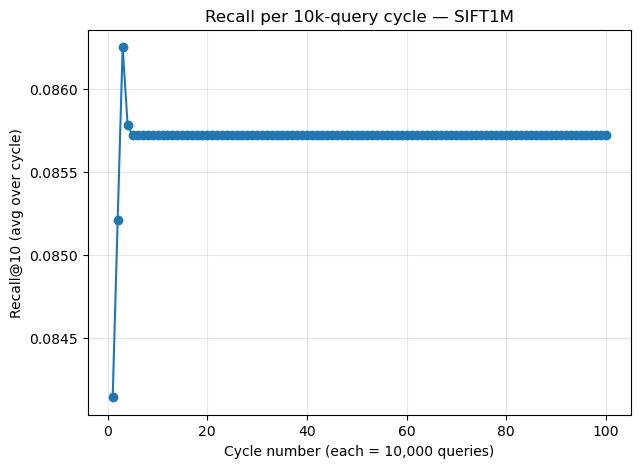

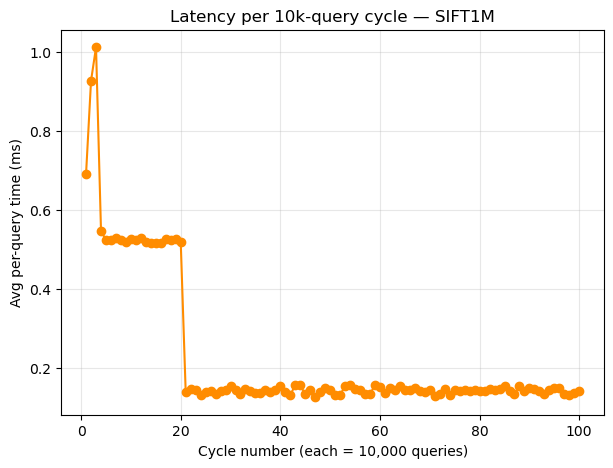

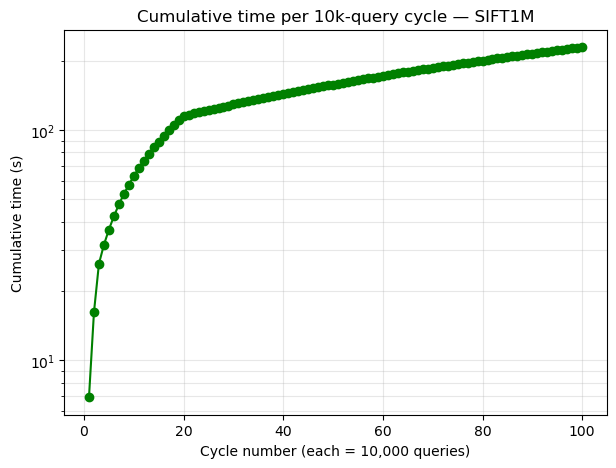

In [40]:
plot_recall_over_trace_10k(sift_result)
plot_latency_over_trace_10k(sift_result)
plot_cumulative_time_10k(sift_result)